In [ ]:
## Library imports
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from loguru import logger

In [236]:
os.makedirs('figures', exist_ok=True)
np.random.seed(42)
df = pd.read_csv("../../data/raw/cars_dataframe.csv", encoding="utf-8")

## This notebook is divided into 4 subsections:
* Section 1: EDA: Exploratory Data Analysis
* Section 2: PCA and Dimensionality reduction
* Section 3: Machine learning: Model training
* Section 4: Model evaluation and metrics 

## First challenge: Cleaning this dataset
### Data Quality & Cleaning Questions
How do we deal with N/A values? — Several columns (Origin, Price, Number of Doors) have missing values.
How do we deal with outliers? — e.g., extreme prices or unusual year/mileage combinations.
How do we handle duplicates and missing values ?
When is the dataset considered clean and ready for ML?

## Exploratory Data Analysis: EDA
Given our 15 columns
**Brand, Model, Year, Condition, Mileage, Gearbox, Fiscal Power, Fuel, Equipment, Number of Doors, Origin, First Owner, Location, Sector, Price**
Let's try to answer the following questions:
### Price Analysis (Target Variable)
1. What is the distribution of car prices? — Is it **normal**, **skewed**, **multimodal**? ✅
2. What is the average/median price by Brand? — Which brands command the highest prices? ✅
3. How does car age (Year) affect price ? (Intuitively, the older the car, the lower the price is) ✅

### Feature Relationships (correlation coefficients)
4. How does Mileage impact Price ? Do higher-mileage cars sell for significantly less? (Intuitively, the answer is **yes**)
5. Does Gearbox type (Manual vs. Automatic) affect price? — And is the effect consistent across brands? ✅
6. Does Condition rating correlate with Price as expected? — Fair < Good < Very Good < Excellent? ✅

### Market Composition
7. What are the most common Brands and Models? — Market share distribution. ✅ 
8. What is the distribution of car Years? — Is the market dominated by recent or older cars? ✅
9. What's the split between Manual vs. Automatic gearboxes? ✅
10. What's the Diesel vs. Petrol distribution? ✅

### Geographic Insights
11. Which Locations/cities have the most listings? ✅
12. Do prices vary by Location? ✅
13. Does the Origin (WW in Morocco, Customs-cleared, etc.) affect pricing? ✅

### Ownership & Equipment
14. Does First Owner (Yes/No) affect price? ✅
15. What are the most common Equipment features? ✅
16. Do more equipped cars command higher prices? ✅

### Multivariate / Correlation
17. What are the strongest correlations with Price ? ✅

# Part 1: The data
## Dealing with Missing Data

In [237]:
rows, cols = df.shape
print(f"Dataset: {rows:,} rows × {cols} columns")

Dataset: 101,896 rows × 15 columns


In [238]:
missing = df.isnull().sum()
percent_missing = (missing.sum() / np.prod(df.shape)) * 100
logger.info(f"About {percent_missing:.2f}% of the data is missing")
print(missing[missing > 0])

2026-04-26 14:20:57.964 | INFO     | __main__:<module>:3 - About 4.43% of the data is missing


Brand                  1
Model                  1
Condition           3583
Mileage                1
Fiscal Power         280
Number of Doors    11415
Origin             11975
First Owner        14700
Sector               246
Price              25483
dtype: int64


## The Missing Data Map

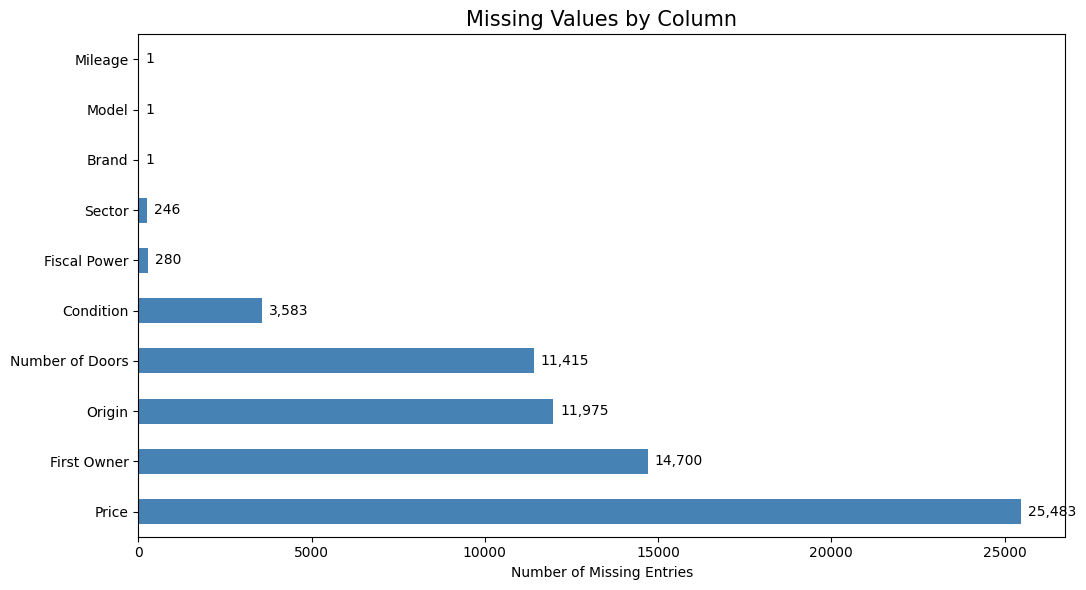

In [239]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
missing_data.plot.barh(ax=ax, color='steelblue')
ax.set_title("Missing Values by Column", fontsize=15)
ax.set_xlabel("Number of Missing Entries")
for p in ax.patches:
    if hasattr(p, "get_width") and hasattr(p, "get_y") and hasattr(p, "get_height"):
        width = float(getattr(p, "get_width")())
        y_center = float(getattr(p, "get_y")()) + float(getattr(p, "get_height")()) / 2
        ax.annotate(
            f"{int(width):,}",
            (width, y_center),
            ha='left',
            va='center',
            fontsize=10,
            xytext=(5, 0),
            textcoords='offset points'
        )
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_01_missing_values_by_column.png'), dpi=150, bbox_inches='tight')
plt.show()

## Q: What do we do with cars that have no Price?

> **Answer:** Drop them! `Price` is our target variable — without it, a record is useless.

In [240]:
missing_price_before = df['Price'].isnull().sum()
df = df.dropna(subset=['Price'])
logger.success(f"Dropped {missing_price_before} rows with missing Price")
logger.info(f"Remaining rows: {df.shape[0]:,}")
assert df['Price'].isnull().sum() == 0

2026-04-26 14:20:58.726 | SUCCESS  | __main__:<module>:3 - Dropped 25483 rows with missing Price
2026-04-26 14:20:58.728 | INFO     | __main__:<module>:4 - Remaining rows: 76,413


## Q: What about the Number of Doors?
> **Answer:** We can **infer** it! Cars of the same Brand, Model, and Year almost always share the same door count.

In [241]:
def fill_doors(df):
    col = 'Number of Doors'
    def group_mode(group_cols):
        return (
            df.dropna(subset=[col])
              .groupby(group_cols)[col]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
    mode_bmy = group_mode(['Brand', 'Model', 'Year'])
    mode_bm  = group_mode(['Brand', 'Model'])
    mode_b   = group_mode(['Brand'])
    overall_mode = df[col].mode().iloc[0]

    def impute(row):
        if pd.notna(row[col]):
            return row[col]
        for key, lookup in [
            ((row['Brand'], row['Model'], row['Year']), mode_bmy),
            ((row['Brand'], row['Model']), mode_bm),
            (row['Brand'], mode_b),
        ]:
            try:
                val = lookup.loc[key]
                if pd.notna(val): return val
            except KeyError:
                pass
        return overall_mode

    df[col] = df.apply(impute, axis=1)
    # Ensure the column type is int64
    df[col] = df[col].astype('int64')
    return df

df = fill_doors(df)
logger.success(f"Missing 'Number of Doors' after imputation: {df['Number of Doors'].isnull().sum()}")

2026-04-26 14:21:01.639 | SUCCESS  | __main__:<module>:35 - Missing 'Number of Doors' after imputation: 0


## Q: What about the other columns?

| Column | Strategy | Why |
|---|---|---|
| `Condition` | **Drop** rows | Can't reliably infer condition |
| `Origin` | **Fill** → `"Unknown"` | Better than losing the row |
| `First Owner` | **Fill** → `"Unknown"` | Could be any owner |
| `Sector` | **Fill** → `"Unknown"` | Optional metadata |
| `Brand / Model` | **Drop** the one bad row (#6714) | No way to recover |

In [242]:
df = df.dropna(subset=['Condition'])
df['Origin'] = df['Origin'].fillna('Unknown')
df['First Owner'] = df['First Owner'].fillna('Unknown')
df['Sector'] = df['Sector'].fillna('Unknown')
df = df.drop(index=6714, errors='ignore')
df.drop_duplicates(inplace=True)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)
df = df[~df['Brand'].str.isnumeric()]
logger.success(f"Clean dataset shape: {df.shape}")

2026-04-26 14:21:01.900 | SUCCESS  | __main__:<module>:11 - Clean dataset shape: (72239, 15)


## Q: What about the Location column?

> **Problem:** Some locations are in French whilst others are in Arabic.
> **Answer:** We need to make this data uniform!

In [243]:
city_mapping = {
    "الدار البيضاء": "Casablanca",
    "الرباط": "Rabat",
    "فاس": "Fès",
    "مراكش": "Marrakech",
    "طنجة": "Tanger",
    "أكادير": "Agadir",
    "وجدة": "Oujda",
    "القنيطرة": "Kénitra",
    "تطوان": "Tétouan",
    "آسفي": "Safi",
    "الجديدة": "El Jadida",
    "العرائش": "Larache",
    "خريبكة": "Khouribga",
    "بني ملال": "Beni Mellal",
    "الناظور": "Nador",
    "العيون": "Laâyoune",
    "الداخلة": "Dakhla",
    "المحمدية": "Mohammedia",
    "مكناس": "Meknès",
    "تمارة": "Temara"
}
## Renaming columns for easier use

In [244]:
new_names_mapping = {'Number of Doors': 'NoD', 'First Owner': 'FO'}
df.rename(columns=new_names_mapping, inplace=True)
logger.success("mapped columns Number of Doors to NoD and First Owner to FO successfully")


2026-04-26 14:21:01.934 | SUCCESS  | __main__:<module>:3 - mapped columns Number of Doors to NoD and First Owner to FO successfully


## Q: What about fiscal power?
> **Answer:** We can **infer** it! Cars of the same Brand, Model, and Year almost always share the same fiscal power.

In [245]:
def fill_fiscal_power(df):
    col = 'Fiscal Power'
    
    def group_mode(group_cols):
        return (
            df.dropna(subset=[col])
              .groupby(group_cols)[col]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
    
    mode_bmy = group_mode(['Brand', 'Model', 'Year'])   # most specific
    mode_bm  = group_mode(['Brand', 'Model'])           # fallback 1
    mode_b   = group_mode(['Brand'])                    # fallback 2
    overall_mode = df[col].mode().iloc[0]               # fallback 3

    def impute(row):
        if pd.notna(row[col]):
            return row[col]
        for key, lookup in [
            ((row['Brand'], row['Model'], row['Year']), mode_bmy),
            ((row['Brand'], row['Model']), mode_bm),
            (row['Brand'], mode_b),
        ]:
            try:
                val = lookup.loc[key]
                if pd.notna(val): return val
            except KeyError:
                pass
        return overall_mode

    df[col] = df.apply(impute, axis=1)
    return df

df = fill_fiscal_power(df)
logger.success(f"Missing 'Fiscal Power' after imputation: {df['Fiscal Power'].isnull().sum()}")
assert df['Fiscal Power'].isnull().sum() == 0

2026-04-26 14:21:07.068 | SUCCESS  | __main__:<module>:35 - Missing 'Fiscal Power' after imputation: 0


## We need to handle outliers (unusual or weird datapoints)

## Q: What is the minimum and maximuim price?

> **Answer:** something is off the minimum price is 1 MAD and the maximum is about 16 Million MAD, not right!

In [246]:
min_price = df.Price.min()
max_price = df.Price.max()
print(f"The minimum price is:  {min_price:.2f} MAD")
print(f"The maximum price is:  {max_price:.2f} MAD")

The minimum price is:  1.00 MAD
The maximum price is:  1600000000.00 MAD


In [247]:
df.Price.sort_values(ascending=True)

34963    1.000000e+00
46247    1.000000e+00
44383    1.000000e+00
30645    1.000000e+00
85052    1.000000e+00
             ...     
39353    9.000000e+08
32541    1.000005e+09
46362    1.111111e+09
45745    1.111111e+09
50882    1.600000e+09
Name: Price, Length: 72239, dtype: float64

In [248]:
# Step 1: Kill known fake values
df["Price"] = df["Price"].replace([1, 2, 5, 10], np.nan)
# Step 2: Drop prices below a domain-informed floor
thereshold = 10_000
df = df[df["Price"] >= 10_000]
## IQR method
Q3 = df.Price.quantile(0.75)
Q1 = df.Price.quantile(0.25)
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["Price"] >= lower) & (df["Price"] <= upper)]

In [249]:
min_price = df.Price.min()
max_price = df.Price.max()
print(f"The minimum price is now:  {min_price:.2f} MAD")
print(f"The maximum price is now:  {max_price:.2f} MAD")

The minimum price is now:  10000.00 MAD
The maximum price is now:  332000.00 MAD


## Optional:
### we can remove values that are so big (like those of luxury cars) for better predictions using our machine learning model


In [250]:
### Removing rare luxury cars that can skew model prediction
# upper = df["Price"].quantile(0.99)
# df = df[df["Price"] <= upper]

In [251]:
mean_price = df.Price.mean()
median_price = df.Price.median()
print(f"The mean price is now:   {mean_price:.2f} MAD")
print(f"The median price is now: {median_price:.2f} MAD")

The mean price is now:   116121.86 MAD
The median price is now: 104000.00 MAD


In [252]:
agg_func = ["min", "max", "mean", "median"]
series = df.Price.agg(agg_func)
stats = list(zip(agg_func, series))
for value in stats:
    print(f"The {value[0]} value is:  {value[1]:.2f} MAD")

The min value is:  10000.00 MAD
The max value is:  332000.00 MAD
The mean value is:  116121.86 MAD
The median value is:  104000.00 MAD


## The Dataset is Now Clean!

In [253]:
missing_after = df.isnull().sum()
total_missing = missing_after[missing_after > 0]
if total_missing.empty:
    print("Zero missing values remaining!")
    print(df.info())
    print(f"We are left with: {df.shape[0]} rows and {df.shape[1]} columns")
else:
    print(total_missing)

Zero missing values remaining!
<class 'pandas.DataFrame'>
Index: 66935 entries, 0 to 101892
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         66935 non-null  str    
 1   Model         66935 non-null  str    
 2   Year          66935 non-null  int64  
 3   Condition     66935 non-null  str    
 4   Mileage       66935 non-null  str    
 5   Gearbox       66935 non-null  str    
 6   Fiscal Power  66935 non-null  str    
 7   Fuel          66935 non-null  str    
 8   Equipment     66935 non-null  str    
 9   NoD           66935 non-null  int64  
 10  Origin        66935 non-null  str    
 11  FO            66935 non-null  str    
 12  Location      66935 non-null  str    
 13  Sector        66935 non-null  str    
 14  Price         66935 non-null  float64
dtypes: float64(1), int64(2), str(12)
memory usage: 20.4 MB
None
We are left with: 66935 rows and 15 columns


# Part 2: The Price Enigma
## Q1: What does the price distribution look like?

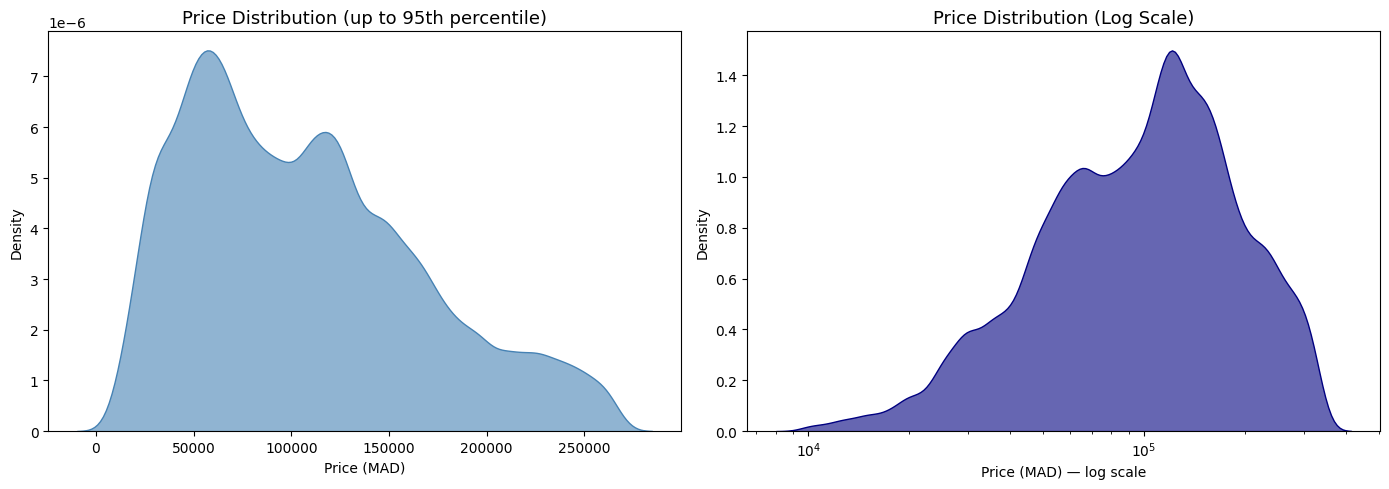

In [254]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

upper = df['Price'].quantile(0.95)
sns.kdeplot(data=df[df['Price'] <= upper], x='Price', fill=True,
            color='steelblue', alpha=0.6, ax=axes[0])
axes[0].set_title('Price Distribution (up to 95th percentile)', fontsize=13)
axes[0].set_xlabel('Price (MAD)')

sns.kdeplot(data=df, x='Price', fill=True, color='navy', alpha=0.6,
            ax=axes[1], log_scale=True)
axes[1].set_title('Price Distribution (Log Scale)', fontsize=13)
axes[1].set_xlabel('Price (MAD) — log scale')

plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_02_price_distribution_up_to_95th_percentile.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q2: Which brands command the highest prices?

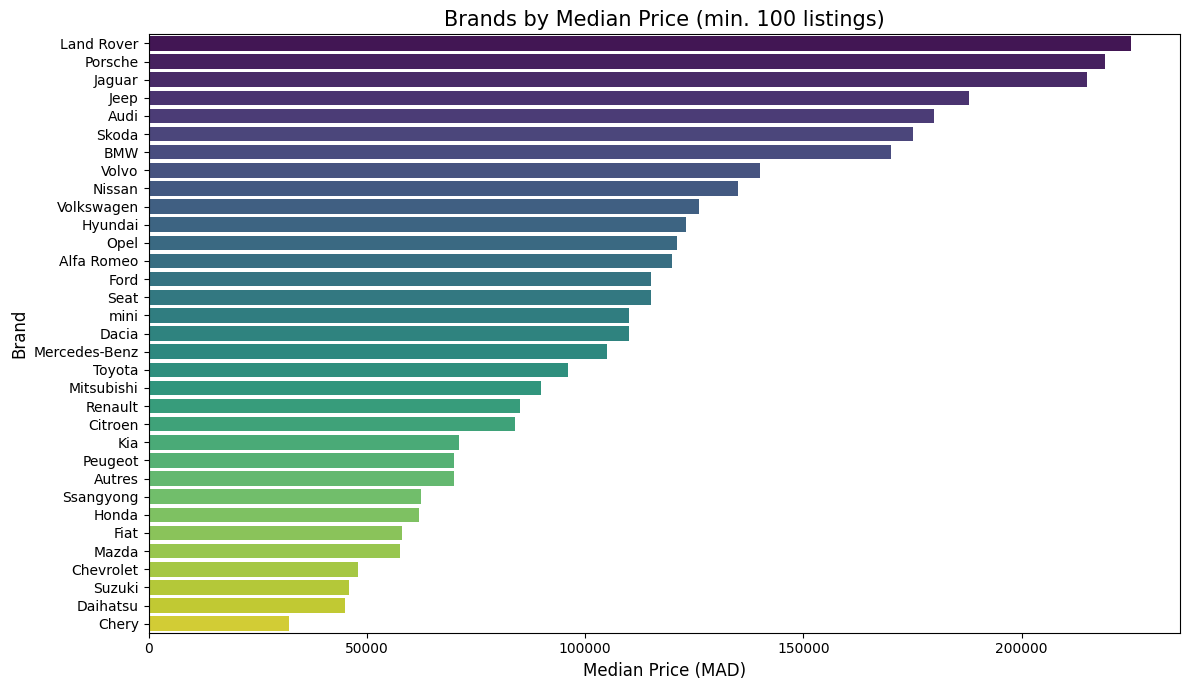

In [255]:
brand_counts = df['Brand'].value_counts()
popular_brands = brand_counts[brand_counts >= 100].index
df_popular = df[df['Brand'].isin(popular_brands)]

median_price = df_popular.groupby('Brand')['Price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=median_price.values, y=median_price.index,
            hue=median_price.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Brands by Median Price (min. 100 listings)', fontsize=15)
ax.set_xlabel('Median Price (MAD)', fontsize=12)
ax.set_ylabel('Brand', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_03_brands_by_median_price_min_100_listings.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q3: Does the year affect the price?

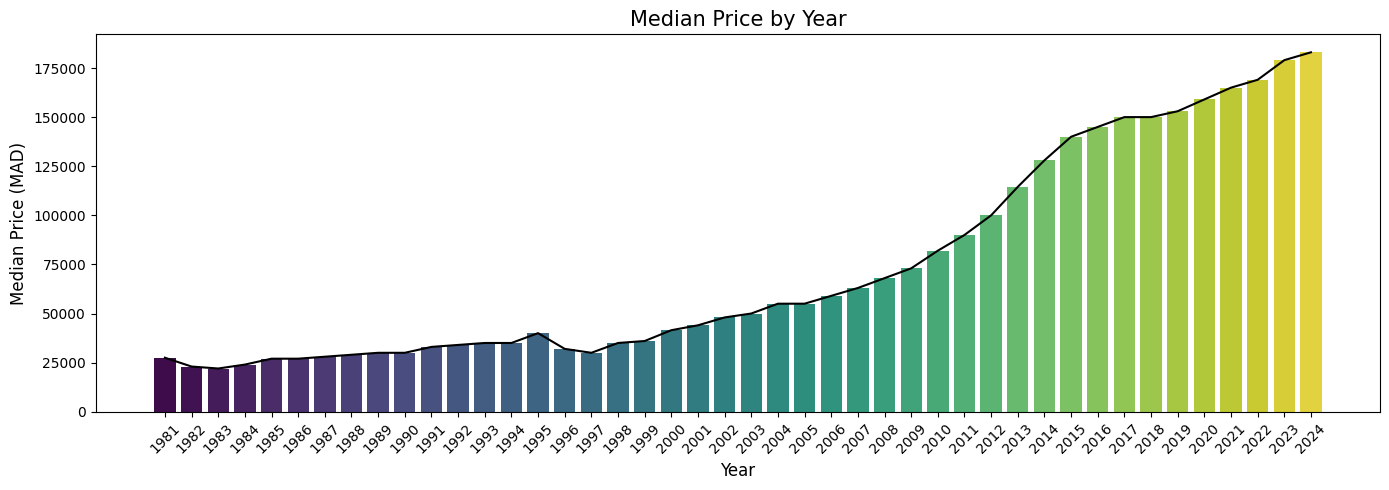

In [256]:
median_by_year = df.groupby('Year')['Price'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=median_by_year, x='Year', y='Price', hue='Year', palette='viridis', legend=False, ax=ax)
ax.plot(range(len(median_by_year)), median_by_year['Price'], color='black', marker=None, linestyle='-', linewidth=1.5)
ax.set_title('Median Price by Year', fontsize=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_04_median_price_by_year.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q4: Manual vs. Automatic — Who pays more?

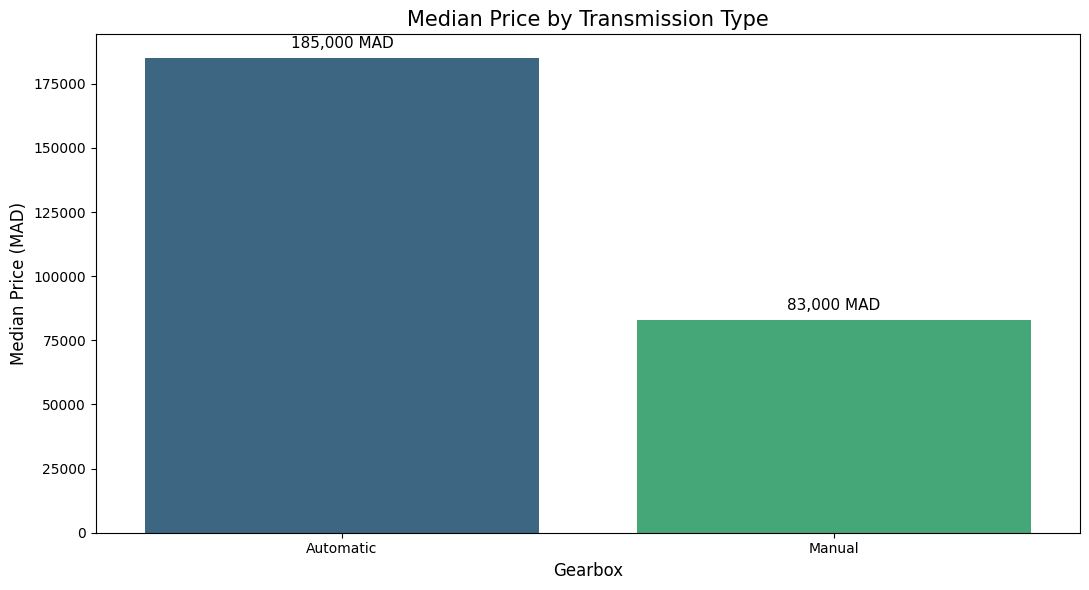

In [257]:
median_price_by_gearbox = df.groupby('Gearbox')['Price'].median().reset_index()
median_price_by_gearbox = median_price_by_gearbox.sort_values(by='Price', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=median_price_by_gearbox, x='Gearbox', y='Price',
            hue='Gearbox', legend=False, palette='viridis', ax=ax)
ax.set_title('Median Price by Transmission Type', fontsize=15)
ax.set_xlabel('Gearbox', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)

for p in ax.patches:
    if hasattr(p, 'get_height') and hasattr(p, 'get_x') and hasattr(p, 'get_width'):
        height = float(getattr(p, 'get_height')())
        x_center = float(getattr(p, 'get_x')()) + float(getattr(p, 'get_width')()) / 2.0
        ax.annotate(
            f"{height:,.0f} MAD",
            (x_center, height),
            ha='center',
            va='bottom',
            fontsize=11,
            xytext=(0, 5),
            textcoords='offset points'
        )
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_05_median_price_by_transmission_type.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q5: Does Condition match our expectations?

In [258]:
df.Condition.unique()

<ArrowStringArray>
['Good', 'Very Good', 'Fair', 'Excellent', 'New', 'For Parts', 'Damaged']
Length: 7, dtype: str

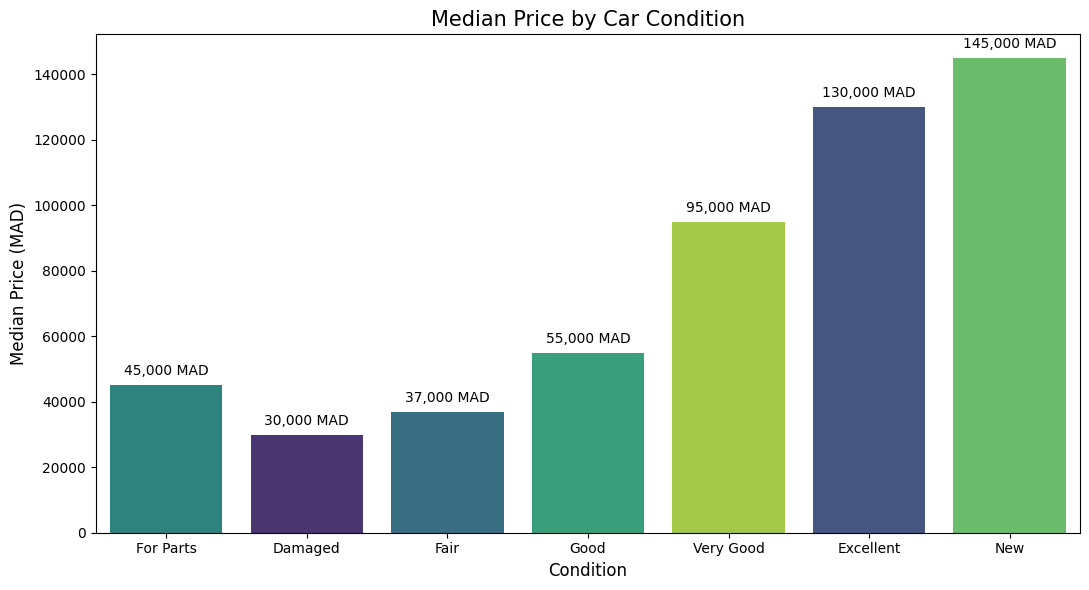

In [259]:
median_price_by_condition = df.groupby('Condition')['Price'].median().reset_index()
condition_order = ['For Parts','Damaged','Fair', 'Good', 'Very Good', 'Excellent', 'New']


fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=median_price_by_condition, x='Condition', y='Price',
            hue='Condition', order=condition_order, legend=False, palette='viridis', ax=ax)
ax.set_title('Median Price by Car Condition', fontsize=15)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)

for p in ax.patches:
    if hasattr(p, 'get_height') and hasattr(p, 'get_x') and hasattr(p, 'get_width'):
        height = float(getattr(p, 'get_height')())
        x_center = float(getattr(p, 'get_x')()) + float(getattr(p, 'get_width')()) / 2.0
        ax.annotate(
            f"{height:,.0f} MAD",
            (x_center, height),
            ha='center',
            va='bottom',
            fontsize=10,
            xytext=(0, 5),
            textcoords='offset points'
        )
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_06_median_price_by_car_condition.png'), dpi=300, bbox_inches='tight')
plt.show()

# Part 3: The Market Map
## Q6: Who dominates the market?

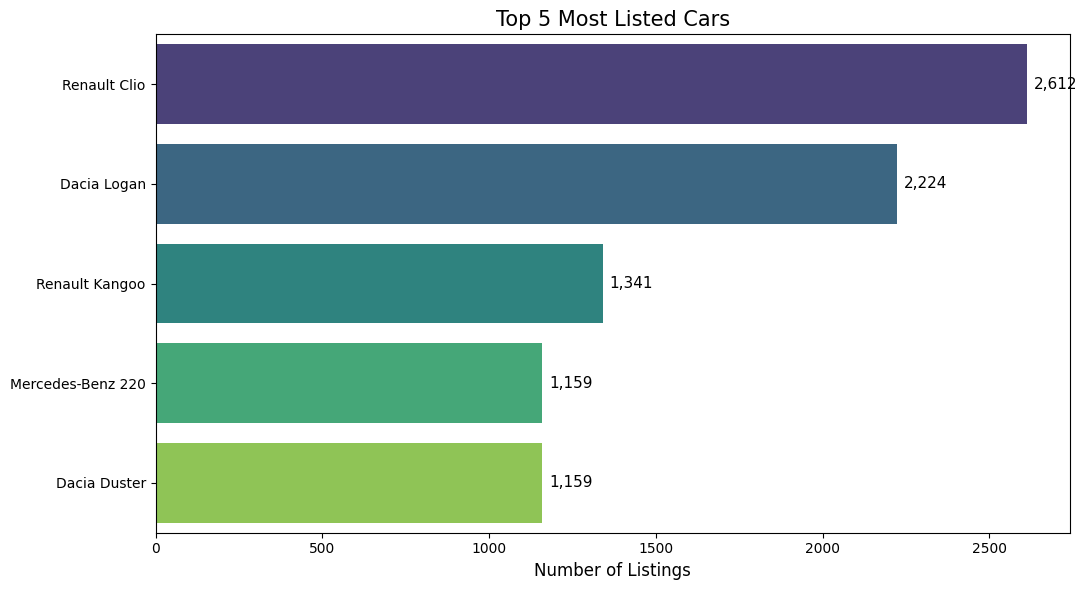

In [260]:
df_plot = df.copy()
df_plot['Car'] = df_plot['Brand'] + ' ' + df_plot['Model']
top_5_cars = df_plot['Car'].value_counts().head(5).reset_index()
top_5_cars.columns = ['Car', 'Count']

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_5_cars, x='Count', y='Car', hue='Car', legend=False, palette='viridis', ax=ax)
ax.set_title('Top 5 Most Listed Cars', fontsize=15)
ax.set_xlabel('Number of Listings', fontsize=12)
ax.set_ylabel('')

for p in ax.patches:
    if hasattr(p, 'get_width') and hasattr(p, 'get_y') and hasattr(p, 'get_height'):
        width = float(getattr(p, 'get_width')())
        y_center = float(getattr(p, 'get_y')()) + float(getattr(p, 'get_height')()) / 2.0
        ax.annotate(
            f"{int(width):,}",
            (width, y_center),
            ha='left',
            va='center',
            fontsize=11,
            xytext=(5, 0),
            textcoords='offset points'
        )
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_07_top_5_most_listed_cars.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q7: Old cars or New cars?

> *We consider New = After 2020. Old = 2020 and before.*

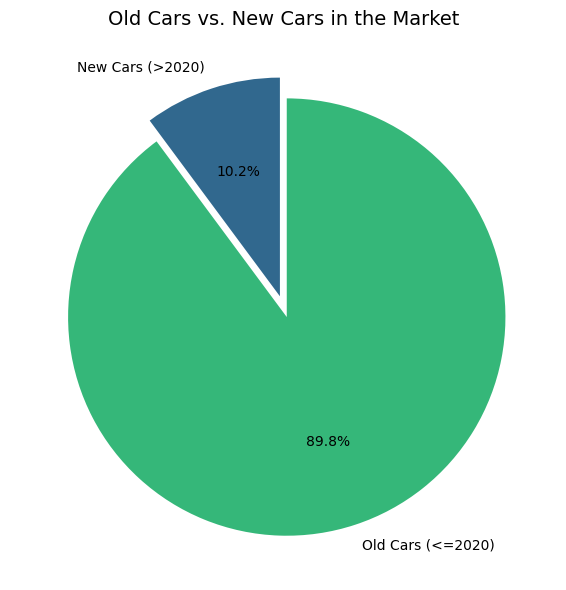

In [261]:
new_cars = df[df['Year'] > 2020]
old_cars = df[df['Year'] <= 2020]

labels = ['New Cars (>2020)', 'Old Cars (<=2020)']
values = np.asarray([new_cars.shape[0], old_cars.shape[0]], dtype=float)
colors = list(sns.color_palette('viridis', n_colors=2))

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05)
    )
ax.set_ylabel('')
ax.set_title('Old Cars vs. New Cars in the Market', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_08_old_cars_vs_new_cars_in_the_market.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q8: Manual or Automatic?

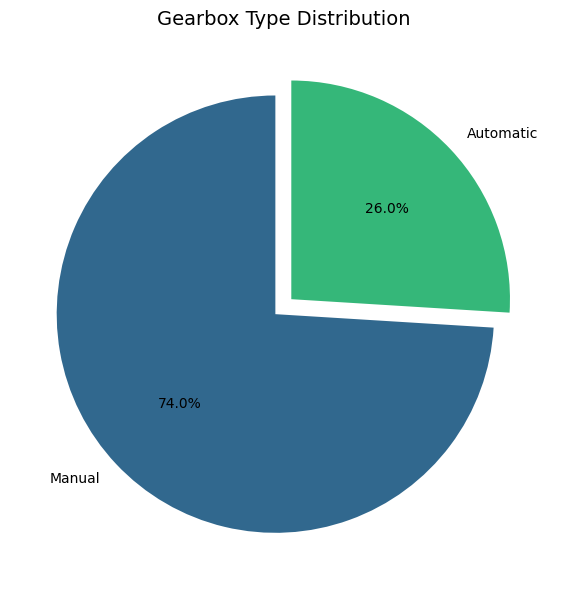

In [262]:
gearbox_counts = df['Gearbox'].value_counts()
labels = gearbox_counts.index.tolist()
values = gearbox_counts.to_numpy(dtype=float)
colors = list(sns.color_palette('viridis', n_colors=2))

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05)
    )
ax.set_ylabel('')
ax.set_title('Gearbox Type Distribution', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_09_gearbox_type_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q9: Diesel or Petrol?

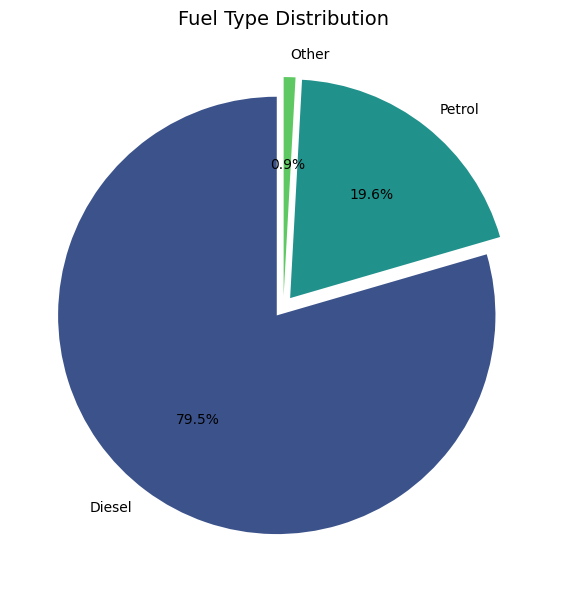

In [263]:
## Since Diesel and Petrol are predominant, let's squash the other categories into 'Other'
fuel_counts = df['Fuel'].value_counts()
fuel_counts['Other'] = fuel_counts[~fuel_counts.index.isin(['Diesel', 'Petrol'])].sum()
fuel_counts = fuel_counts[['Diesel', 'Petrol', 'Other']]

labels = fuel_counts.index.tolist()
values = fuel_counts.to_numpy(dtype=float)
colors = list(sns.color_palette('viridis', n_colors=3))

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05, 0.05)
    )
ax.set_ylabel('')
ax.set_title('Fuel Type Distribution', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_10_fuel_type_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# Part 4: The Geographic Trail
## Q10: Where are all these cars coming from?

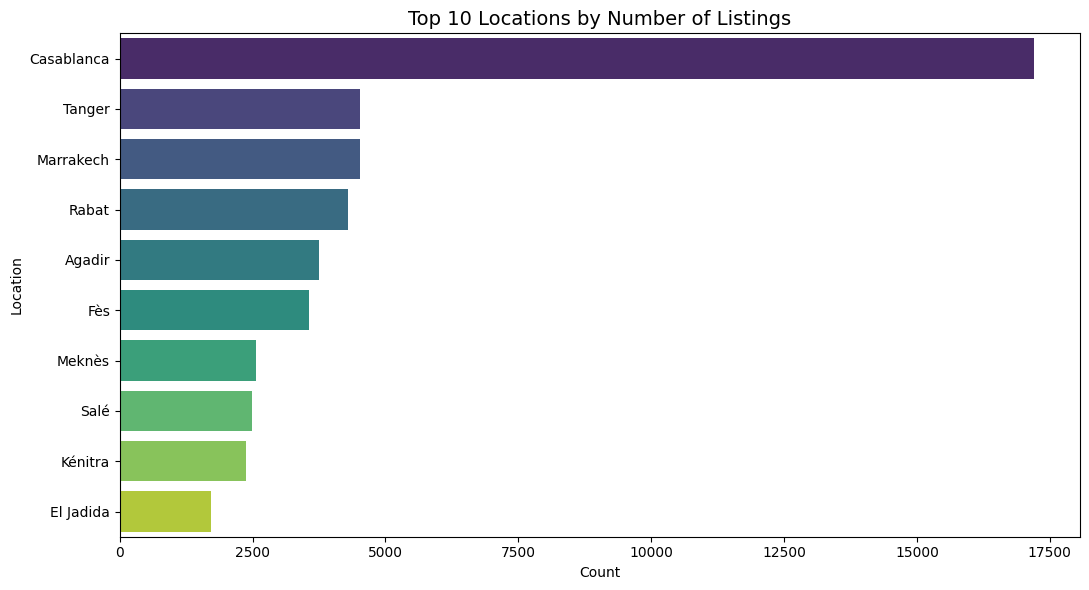

In [264]:
loc_counts = df['Location'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=loc_counts.values, y=loc_counts.index,
            hue=loc_counts.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Top 10 Locations by Number of Listings', fontsize=14)
ax.set_xlabel('Count')
ax.set_ylabel('Location')
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_11_top_10_locations_by_number_of_listings.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q11: Where are the most expensive cars?

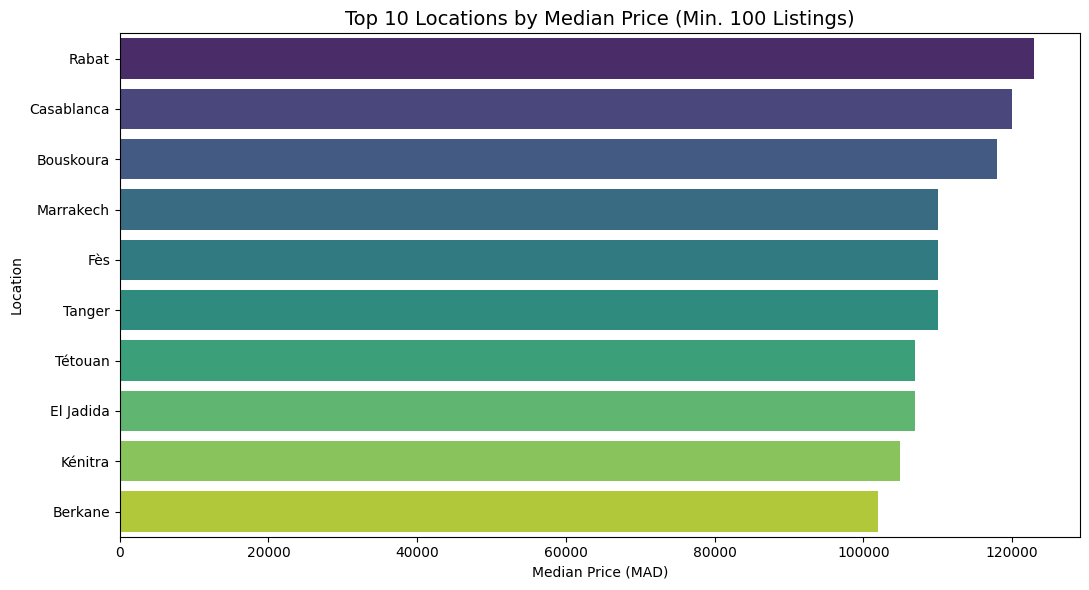

In [265]:
# First, filter to locations that have at least 100 listings
threshold = 100
loc_counts = df['Location'].value_counts()
popular_locs = loc_counts[loc_counts >= threshold].index
df_popular_loc = df[df['Location'].isin(popular_locs)]

median_price_loc = df_popular_loc.groupby('Location')['Price'].median().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=median_price_loc.values, y=median_price_loc.index,
            hue=median_price_loc.index, legend=False, palette='viridis', ax=ax)
ax.set_title(f'Top 10 Locations by Median Price (Min. {threshold} Listings)', fontsize=14)
ax.set_xlabel('Median Price (MAD)')
ax.set_ylabel('Location')
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_12.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q12: Does the Origin affect price?

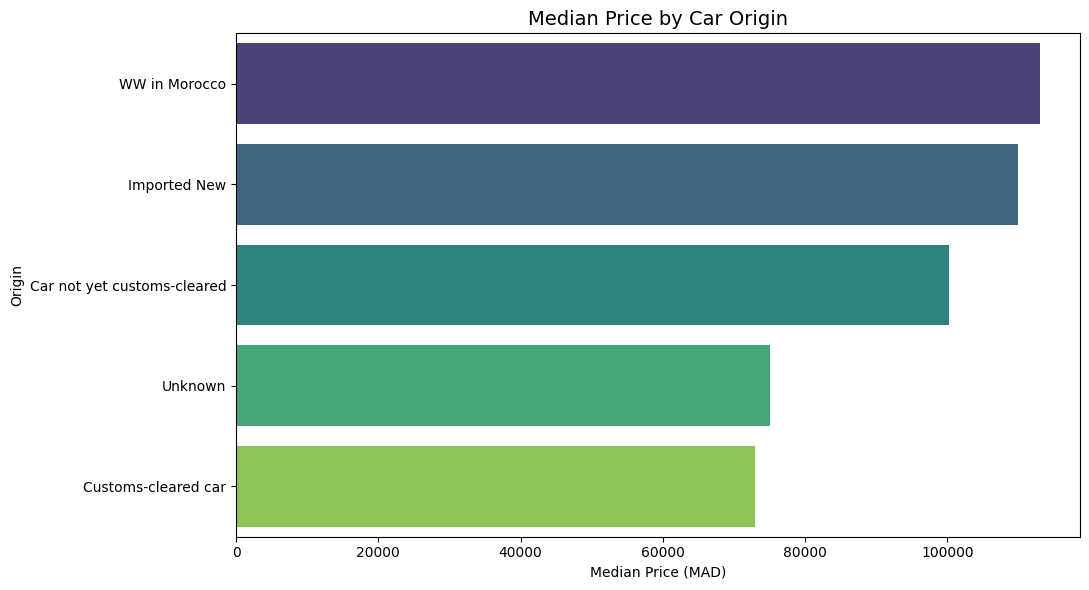

In [266]:
median_price_origin = df.groupby('Origin')['Price'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=median_price_origin.values, y=median_price_origin.index,
            hue=median_price_origin.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Median Price by Car Origin', fontsize=14)
ax.set_xlabel('Median Price (MAD)')
ax.set_ylabel('Origin')

plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_13_median_price_by_car_origin.png'), dpi=300, bbox_inches='tight')
plt.show()

# Part 5: The Hidden Factors
## Q13: Does being First Owner matter?

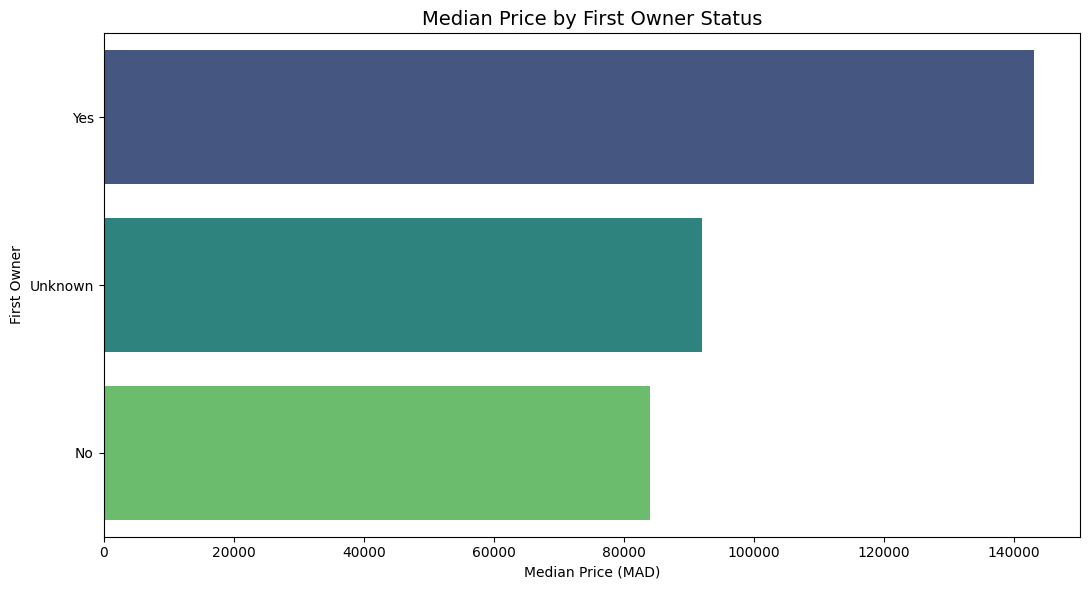

In [267]:
median_price_owner = df.groupby('FO')['Price'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=median_price_owner.values, y=median_price_owner.index,
            hue=median_price_owner.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Median Price by First Owner Status', fontsize=14)
ax.set_xlabel('Median Price (MAD)')
ax.set_ylabel('First Owner')
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_14_median_price_by_first_owner_status.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q14: What equipment features are most common?

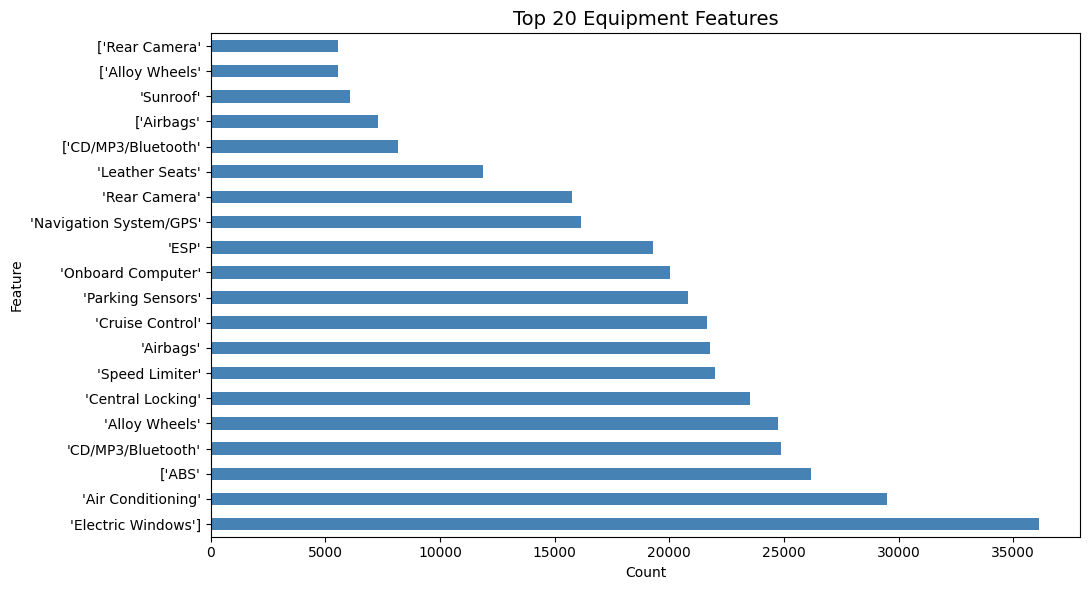

In [268]:
equip_series = df['Equipment'].dropna().str.split(',', expand=True).stack().str.strip().value_counts()

fig, ax = plt.subplots(figsize=(11, 6))
equip_series.head(20).plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 20 Equipment Features', fontsize=14)
ax.set_xlabel('Count')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_15_top_20_equipment_features.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q15: Do more features = higher price?

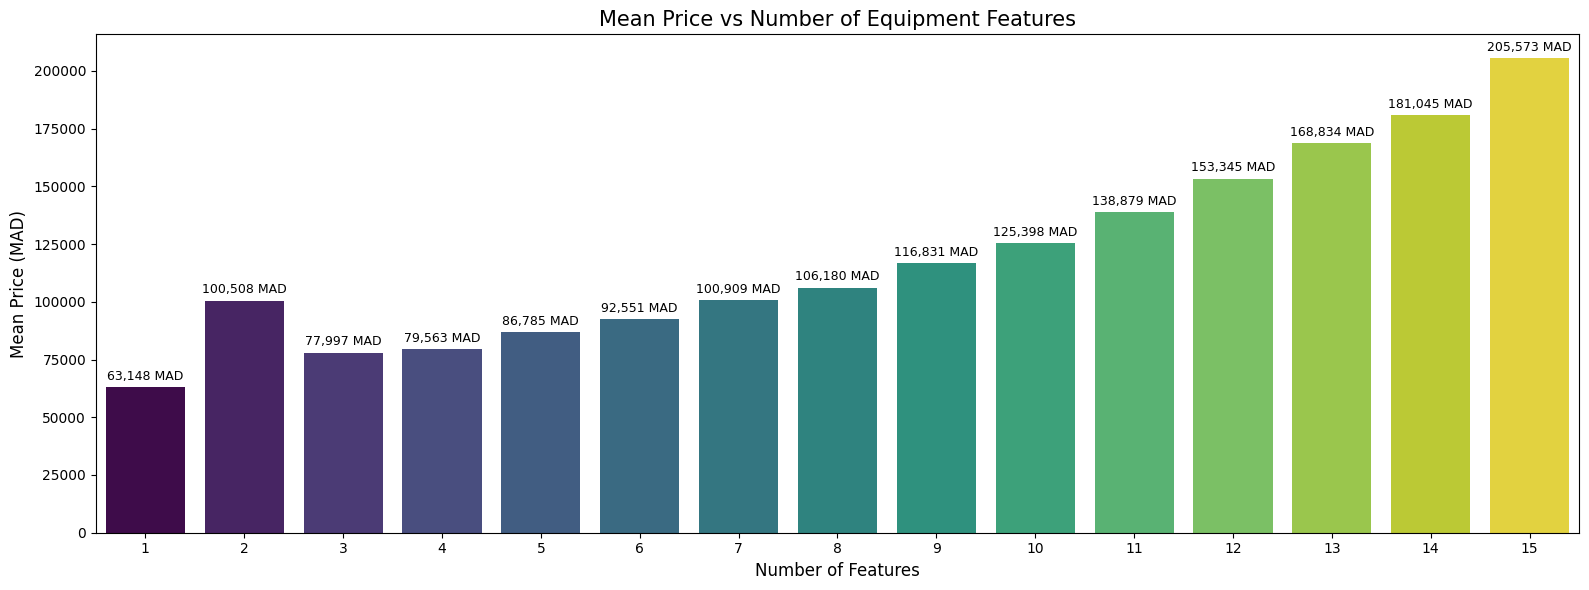

In [269]:
## We'd like to plot mean price vs Number of features
## and y Axis is the mean price in MAD
df['num_features'] = df['Equipment'].fillna('').apply(
    lambda s: len([x for x in s.split(',') if x.strip() != ''])
)

mean_price = df.groupby('num_features')['Price'].mean().reset_index()
mean_price.columns = ['Number of Features', 'Mean Price']

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=mean_price, x='Number of Features', y='Mean Price',
            hue='Number of Features', legend=False, palette='viridis', ax=ax)
ax.set_title('Mean Price vs Number of Equipment Features', fontsize=15)
ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('Mean Price (MAD)', fontsize=12)

for p in ax.patches:
    if hasattr(p, 'get_height') and hasattr(p, 'get_x') and hasattr(p, 'get_width'):
        height = float(getattr(p, 'get_height')())
        if height > 0:
            x_center = float(getattr(p, 'get_x')()) + float(getattr(p, 'get_width')()) / 2.0
            ax.annotate(
                f"{height:,.0f} MAD",
                (x_center, height),
                ha='center',
                va='bottom',
                fontsize=9,
                xytext=(0, 3),
                textcoords='offset points'
            )
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_16_mean_price_vs_number_of_features.png'), dpi=300, bbox_inches='tight')
plt.show()

In [270]:
condition_order = ['For Parts', 'Damaged', 'Fair', 'Good', 'Very Good', 'Excellent', 'New']
condition_map = {cond: i / (len(condition_order) - 1) for i, cond in enumerate(condition_order)}
print('Condition mapping:')
for k, v in condition_map.items():
    print(f'  {k:>15s}  ->  {v:.2f}')

df['condition_numeric'] = df['Condition'].map(condition_map)
logger.success(f'\nMissing values after mapping: {df["condition_numeric"].isna().sum()}')

2026-04-26 14:21:25.306 | SUCCESS  | __main__:<module>:8 - 
Missing values after mapping: 0


Condition mapping:
        For Parts  ->  0.00
          Damaged  ->  0.17
             Fair  ->  0.33
             Good  ->  0.50
        Very Good  ->  0.67
        Excellent  ->  0.83
              New  ->  1.00


# Part 6: The Big Picture
## Q16: What actually correlates with price?

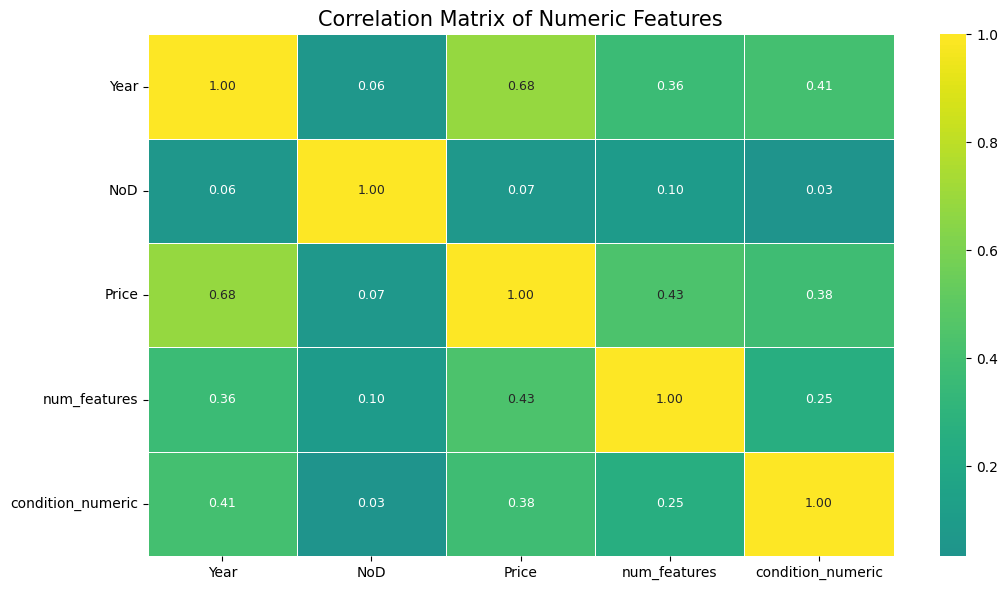

In [271]:
numeric = df.select_dtypes(include=[np.number])
corr_matrix = numeric.corr()

plt.figure(figsize=(11, 6))
sns.heatmap(corr_matrix, cmap='viridis', center=0, annot=True, fmt=".2f",
            linewidths=0.5, annot_kws={"size": 9})
plt.title('Correlation Matrix of Numeric Features', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_17_correlation_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

In [272]:
df.columns

Index(['Brand', 'Model', 'Year', 'Condition', 'Mileage', 'Gearbox',
       'Fiscal Power', 'Fuel', 'Equipment', 'NoD', 'Origin', 'FO', 'Location',
       'Sector', 'Price', 'num_features', 'condition_numeric'],
      dtype='str')

# Section 2: PCA and Dimensionality reduction

## Before training our model, we need to do a couple of things first
- Drop all the rows with no price label (Done ✅)
- Encode categorical columns (Work in progress 🔨)

In [273]:
## Firt thing we should know, our data dimensions
rows, cols = df.shape
print(f"We have {rows} rows and {cols} columns")

We have 66935 rows and 17 columns


In [274]:
col_names = list(df.columns)
## We should encode useful categorical data in numeric format
## Encoding First Owner to a binary format (0 or 1)

| Column | Strategy |
| :--- | :--- |
| `Brand`, `Model` | Target Encoding (high cardinality) |
| `Gearbox`, `Fuel`, `Origin` | One-Hot Encoding |
| `Location`, `Sector` | Target Encoding or drop if too noisy |
| `F0` (First Owner) | Binary encode (Yes/No $\rightarrow$ 1/0) |
| `Condition` | Already done $\rightarrow$ `condition_numeric` ✅ |
| `Equipment` | Already done $\rightarrow$ `num_features` ✅ |

### First let's encode First Owner into a binary format

In [275]:
df.FO.value_counts()
FO_mapping = {"Yes": 1, "No": 0, "Unknown": 0}
df['FO'] = df['FO'].map(FO_mapping)

In [276]:
## Let's add a log_price column
df['Price_log']   = np.log1p(df['Price'])

In [277]:
## Problem with mileage column is that it's a range in format digit - digit example: 200 000 - 249 999 etc...
def mileage_to_mean(mileage_str):
    try:
        if pd.isna(mileage_str):
            return None
        
        # Normalize string
        mileage_str = mileage_str.replace(" ", "").lower()
        
        # Case 1: "plusdeXXXXX"
        if "plusde" in mileage_str:
            value = int(re.findall(r"\d+", mileage_str)[0])
            return value  # or value * 1.1
        
        # Case 2: range
        if "-" in mileage_str:
            low, high = mileage_str.split("-")
            return (int(low) + int(high)) / 2
        
        # Case 3: single value
        return int(mileage_str)
    
    except:
        return None

df["Mileage_mean"] = df["Mileage"].apply(mileage_to_mean)

In [278]:
## Getting rid of cars with high mileage
df = df[df["Mileage_mean"] < 400000]

In [279]:
## Encoding Fiscal Power to an int
df["Fiscal Power"] = df["Fiscal Power"].str.extract(r"(\d+)\s*CV").astype(int)

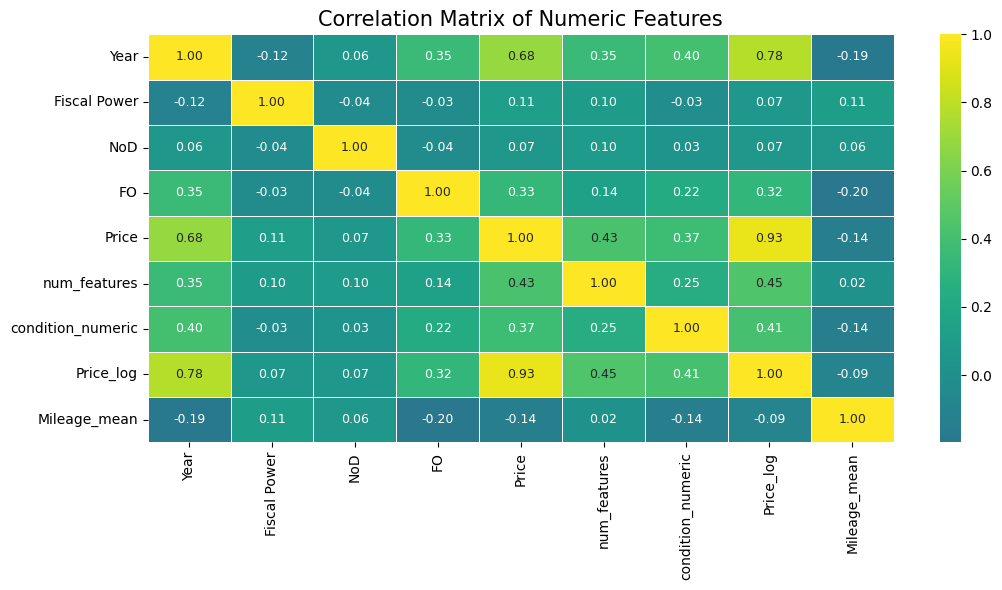

In [280]:
numeric = df.select_dtypes(include=[np.number])
corr_matrix = numeric.corr()

plt.figure(figsize=(11, 6))
sns.heatmap(corr_matrix, cmap='viridis', center=0, annot=True, fmt=".2f",
            linewidths=0.5, annot_kws={"size": 9})
plt.title('Correlation Matrix of Numeric Features', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'fig_17_correlation_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Saving the Cleaned Data

Let's save our squeaky clean dataset before moving on to the next chapter!

## Saving this data as .csv file to continue with Section 3: Training a machine learning algorithm


In [281]:
## Saving this data as .csv file to continue with Section 3: Training a machine learning algorithm
filename = "cleaned_data_ready_for_ml.csv"
df.to_csv(filename, index=False, encoding="utf-8")
logger.success(f"Dataset successfully saved as '{filename}'!")

2026-04-26 14:21:30.770 | SUCCESS  | __main__:<module>:4 - Dataset successfully saved as 'cleaned_data_ready_for_ml.csv'!
